In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
file = pd.read_csv('../data/raw/aniversariantes_anpla.csv', parse_dates=['Data de Nascimento'], dayfirst=True)
file

,Nome,Data de Nascimento,Idade
0,Adelson Rodrigues,1969-11-25,56
1,Adriana Barandof de Souza Silveira,1972-04-16,54
2,Adriana de Lemos Antunes,1981-06-12,45
3,Adriana Rocha Silva,1973-08-30,53
4,Adriano Pereira de Oliveira,1981-02-19,45
...,...,...,...
315,Wilton Pinheiro da Costa,1963-11-25,62
316,Wladimir Wanderley Pereira,1979-01-30,47
317,Yagho da Silva Grijo,1994-02-06,32
318,Yasmin Chiodi Malafaia,2001-09-02,24


In [4]:
file.info()

<class 'pandas.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Nome                320 non-null    str           
 1   Data de Nascimento  320 non-null    datetime64[us]
 2   Idade               320 non-null    int64         
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 7.6 KB


In [ ]:
meses = {
    1: 'Janeiro',
    2: 'Fevereiro',
    3: 'Março',
    4: 'Abril',
    5: 'Maio',
    6: 'Junho',
    7: 'Julho',
    8: 'Agosto',
    9: 'Setembro',
    10: 'Outubro',
    11: 'Novembro',
    12: 'Dezembro'
}

file['Mes'] = file['Data de Nascimento'].dt.month.map(meses)

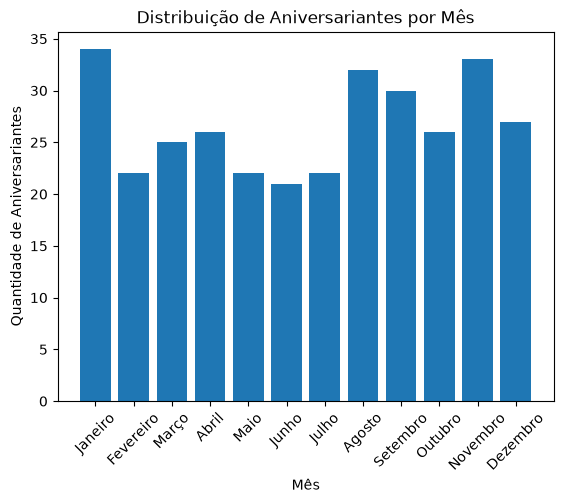

In [6]:
ordem_meses = list(meses.values())

file['Mes'] = pd.Categorical(
    file['Mes'],
    categories=ordem_meses,
    ordered=True
)

resultado = file.groupby('Mes', observed=True)['Idade'].size().values

plt.bar(ordem_meses, resultado)
plt.xlabel('Mês')
plt.ylabel('Quantidade de Aniversariantes')
plt.xticks(rotation=45)
plt.title('Distribuição de Aniversariantes por Mês'); # O ; ponto e vírgula no final é para tirar a saída do objeto de textono Notebook

In [13]:
faixas = [0, 18, 23, 28, 33, 38, 43, 48, 53, 58, 120]

faixa_etaria = {
    1: '0 a 18',
    2: '19 a 23',
    3: '24 a 28',
    4: '29 a 33',
    5: '34 a 38',
    6: '39 a 43',
    7: '44 a 48',
    8: '49 a 53',
    9: '54 a 58',
    10: '59+'
}

file['Faixa'] = pd.cut(
    file['Idade'],
    bins=faixas,
    labels=faixa_etaria,
    include_lowest=True
).map(faixa_etaria)

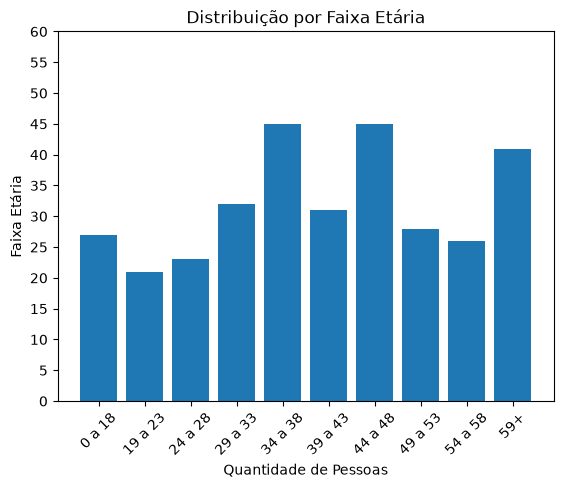

In [17]:
resultado = file.groupby('Faixa', observed=True).size()

plt.bar(resultado.index, resultado.values)

plt.ylabel('Faixa Etária')
plt.xlabel('Quantidade de Pessoas')
plt.xticks(rotation=45)
plt.yticks(np.array(range(0, 65, 5)))
plt.title('Distribuição por Faixa Etária'); # O ; ponto e vírgula no final é para tirar a saída do objeto de textono Notebook

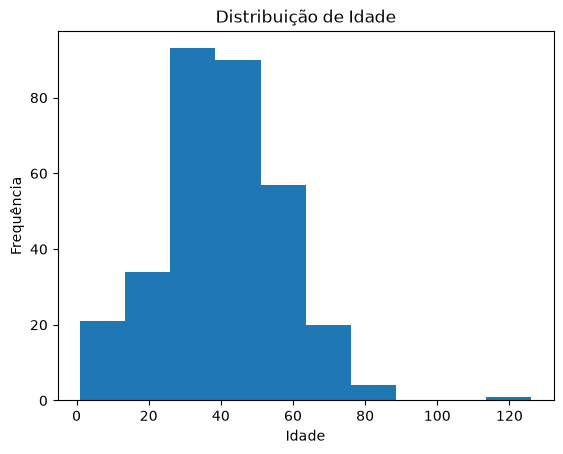

In [25]:
plt.hist(file['Idade'])
plt.title('Distribuição de Idade')
plt.xlabel('Idade')
plt.ylabel('Frequência');